<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/08_pytorch_paper_replicating_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08. PyTorch Paper Replicating Exercises

Welcome to the 08. PyTorch Paper Replicating exercises.

Your objective is to write code to satisify each of the exercises below.

Some starter code has been provided to make sure you have all the resources you need.

> **Note:** There may be more than one solution to each of the exercises.

## Resources

1. These exercises/solutions are based on [section 08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/tjpW_BY8y3g) (but try the exercises yourself first!).
3. See [all solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

> **Note:** The first section of this notebook is dedicated to getting various helper functions and datasets used for the exercises. The exercises start at the heading "Exercise 1: ...".

### Get various imports and helper functions

The code in the following cells prepares imports and data for the exercises below. They are taken from [08. PyTorch Paper Replicating](https://www.learnpytorch.io/08_pytorch_paper_replicating/). 

In [1]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U --pre torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/nightly/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")


torch version: 2.14.0+cpu
torchvision version: 0.29.0+cpu


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    %pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except ImportError:
    # This repo already has going_modular/ and helper_functions.py two directories up
    # (../../), so point Python at them instead of git-cloning the whole repo again.
    import sys
    from pathlib import Path

    def has_both(p):
        return (p / "going_modular").is_dir() and (p / "helper_functions.py").is_file()

    repo_root = Path.cwd()
    while not has_both(repo_root) and repo_root != repo_root.parent:
        repo_root = repo_root.parent

    if has_both(repo_root):
        print(f"[INFO] Found going_modular/helper_functions at {repo_root}, adding it to sys.path.")
        sys.path.insert(0, str(repo_root / "going_modular"))
        sys.path.insert(0, str(repo_root))
        from going_modular import data_setup, engine
        from helper_functions import download_data, set_seeds, plot_loss_curves
    else:
        print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
        !git clone https://github.com/mrdbourke/pytorch-deep-learning
        !mv pytorch-deep-learning/going_modular .
        !mv pytorch-deep-learning/helper_functions.py .
        !rm -rf pytorch-deep-learning
        from going_modular.going_modular import data_setup, engine
        from helper_functions import download_data, set_seeds, plot_loss_curves

[INFO] Found going_modular/helper_functions at D:\computer vision\baith02_cv_DoanThiThuLinh\pytorch-deep-learning, adding it to sys.path.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Get data

Want to download the data we've been using in PyTorch Paper Replicating: https://www.learnpytorch.io/08_pytorch_paper_replicating/#1-get-data

In [4]:
# Download pizza, steak, sushi images from GitHub
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")
image_path

[INFO] data\pizza_steak_sushi directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi')

In [5]:
# Setup directory paths to train and test images
train_dir = image_path / "train"
test_dir = image_path / "test"

### Preprocess data

Turn images into tensors using same code as PyTorch Paper Replicating section 2.1 and 2.2: https://www.learnpytorch.io/08_pytorch_paper_replicating/#21-prepare-transforms-for-images

In [6]:
# Create image size (from Table 3 in the ViT paper) 
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])           
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [7]:
# Set the batch size
BATCH_SIZE = 32 # this is lower than the ViT paper but it's because we're starting small

# Create data loaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, # use manually created transforms
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x24cff3ed010>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(0))

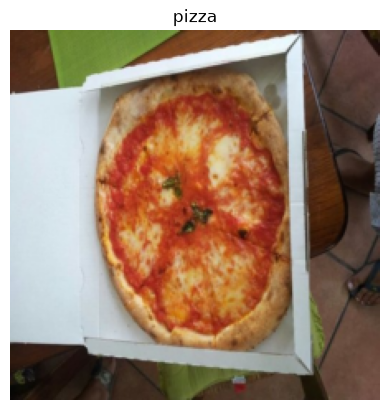

In [9]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

## 1. Replicate the ViT architecture we created with in-built [PyTorch transformer layers](https://pytorch.org/docs/stable/nn.html#transformer-layers).

* You'll want to look into replacing our `TransformerEncoderBlock()` class with [`torch.nn.TransformerEncoderLayer()`](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html#torch.nn.TransformerEncoderLayer) (these contain the same layers as our custom blocks). 
* You can stack `torch.nn.TransformerEncoderLayer()`'s on top of each other with [`torch.nn.TransformerEncoder()`](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html#torch.nn.TransformerEncoder).

In [10]:
# Exercise 1: replicate the ViT architecture using PyTorch's built-in transformer layers
# (nn.TransformerEncoderLayer + nn.TransformerEncoder instead of hand-written
# MultiheadSelfAttentionBlock / MLPBlock / TransformerEncoderBlock classes).

class PatchEmbedding(nn.Module):
  """Turns a 2D input image into a 1D sequence of learnable patch embeddings."""
  def __init__(self, in_channels=3, patch_size=16, embedding_dim=768):
    super().__init__()
    self.patch_size = patch_size
    # Use a Conv2d to both split the image into patches AND linearly embed each patch
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0)
    self.flatten = nn.Flatten(start_dim=2, end_dim=3)

  def forward(self, x):
    image_resolution = x.shape[-1]
    assert image_resolution % self.patch_size == 0, \
        f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"
    x_patched = self.patcher(x)             # [batch, embedding_dim, n_patches_h, n_patches_w]
    x_flattened = self.flatten(x_patched)    # [batch, embedding_dim, n_patches]
    return x_flattened.permute(0, 2, 1)      # [batch, n_patches, embedding_dim]


class ViT(nn.Module):
  """Vision Transformer (ViT-Base), built with torch.nn.TransformerEncoderLayer."""
  def __init__(self,
              img_size=224,
              in_channels=3,
              patch_size=16,
              num_transformer_layers=12,  # ViT-Base, Table 1 in the ViT paper
              embedding_dim=768,           # ViT-Base
              mlp_size=3072,                # ViT-Base
              num_heads=12,                 # ViT-Base
              attn_dropout=0,
              mlp_dropout=0.1,
              embedding_dropout=0.1,
              num_classes=1000):
    super().__init__()

    assert img_size % patch_size == 0, "Image size must be divisible by patch size."
    self.num_patches = (img_size * img_size) // patch_size**2

    # Learnable [class] token, prepended to the patch sequence
    self.class_embedding = nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True)

    # Learnable 1D position embedding, one per patch + one for the class token
    self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embedding_dim), requires_grad=True)

    self.embedding_dropout = nn.Dropout(p=embedding_dropout)

    self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    # torch.nn.TransformerEncoderLayer already contains the same sub-layers as our
    # custom TransformerEncoderBlock would: MSA block + MLP block, each with a residual
    # connection and LayerNorm ("pre-norm" via norm_first=True, matching the ViT paper).
    encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim,
                                                nhead=num_heads,
                                                dim_feedforward=mlp_size,
                                                dropout=mlp_dropout,
                                                activation="gelu",
                                                batch_first=True,
                                                norm_first=True)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=encoder_layer,
                                                      num_layers=num_transformer_layers)

    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim, out_features=num_classes)
    )

  def forward(self, x):
    batch_size = x.shape[0]

    class_token = self.class_embedding.expand(batch_size, -1, -1) # [batch, 1, embedding_dim]

    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)      # prepend class token
    x = self.position_embedding + x             # add position embeddings
    x = self.embedding_dropout(x)

    x = self.transformer_encoder(x)

    # Only the class token's output is used for classification (index 0)
    x = self.classifier(x[:, 0])
    return x


# Quick sanity check: instantiate and run a forward pass on a real batch of images
set_seeds()
vit = ViT(num_classes=len(class_names)).to(device)

image_batch, label_batch = next(iter(train_dataloader))
vit_output = vit(image_batch.to(device))
print(f"Input shape: {image_batch.shape}")
print(f"Output shape: {vit_output.shape} (should be [batch_size, num_classes])")

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 3]) (should be [batch_size, num_classes])


In [11]:
summary(model=vit,
       input_size=(1, 3, 224, 224),
       col_names=["input_size", "output_size", "num_params", "trainable"],
       col_width=20,
       row_settings=["var_names"])

Layer (type (var_name))                                 Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                               [1, 3, 224, 224]     [1, 3]               152,064              True
├─PatchEmbedding (patch_embedding)                      [1, 3, 224, 224]     [1, 196, 768]        --                   True
│    └─Conv2d (patcher)                                 [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
│    └─Flatten (flatten)                                [1, 768, 14, 14]     [1, 768, 196]        --                   --
├─Dropout (embedding_dropout)                           [1, 197, 768]        [1, 197, 768]        --                   --
├─TransformerEncoder (transformer_encoder)              [1, 197, 768]        [1, 197, 768]        --                   True
│    └─ModuleList (layers)                              --                   --                   --                   True
│    │ 

## 2. Turn the custom ViT architecture we created into a Python script, for example, `vit.py`.

* You should be able to import an entire ViT model using something like`from vit import ViT`.
* We covered the art of turning code cells into Python scrips in [05. PyTorch Going Modular](https://www.learnpytorch.io/05_pytorch_going_modular/). 


In [12]:
%%writefile vit.py
"""
Contains a from-scratch PyTorch implementation of the ViT-Base architecture
(Dosovitskiy et al. 2020, "An Image is Worth 16x16 Words"), built on top of
torch.nn.TransformerEncoderLayer.

Example usage:
  from vit import ViT
  model = ViT(num_classes=3)
"""
import torch
from torch import nn


class PatchEmbedding(nn.Module):
  """Turns a 2D input image into a 1D sequence of learnable patch embeddings."""
  def __init__(self, in_channels: int = 3, patch_size: int = 16, embedding_dim: int = 768):
    super().__init__()
    self.patch_size = patch_size
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0)
    self.flatten = nn.Flatten(start_dim=2, end_dim=3)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    image_resolution = x.shape[-1]
    assert image_resolution % self.patch_size == 0, \
        f"Input image size must be divisible by patch size, image shape: {image_resolution}, patch size: {self.patch_size}"
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)
    return x_flattened.permute(0, 2, 1)


class ViT(nn.Module):
  """Creates a Vision Transformer (ViT-Base) architecture."""
  def __init__(self,
              img_size: int = 224,
              in_channels: int = 3,
              patch_size: int = 16,
              num_transformer_layers: int = 12,
              embedding_dim: int = 768,
              mlp_size: int = 3072,
              num_heads: int = 12,
              attn_dropout: float = 0,
              mlp_dropout: float = 0.1,
              embedding_dropout: float = 0.1,
              num_classes: int = 1000):
    super().__init__()

    assert img_size % patch_size == 0, "Image size must be divisible by patch size."
    self.num_patches = (img_size * img_size) // patch_size**2

    self.class_embedding = nn.Parameter(torch.randn(1, 1, embedding_dim), requires_grad=True)
    self.position_embedding = nn.Parameter(torch.randn(1, self.num_patches + 1, embedding_dim), requires_grad=True)
    self.embedding_dropout = nn.Dropout(p=embedding_dropout)

    self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim,
                                                nhead=num_heads,
                                                dim_feedforward=mlp_size,
                                                dropout=mlp_dropout,
                                                activation="gelu",
                                                batch_first=True,
                                                norm_first=True)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=encoder_layer,
                                                      num_layers=num_transformer_layers)

    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim, out_features=num_classes)
    )

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    batch_size = x.shape[0]
    class_token = self.class_embedding.expand(batch_size, -1, -1)

    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)
    x = self.position_embedding + x
    x = self.embedding_dropout(x)

    x = self.transformer_encoder(x)
    return self.classifier(x[:, 0])

Writing vit.py


In [13]:
# Demonstrate importing the freshly written script
from vit import ViT as ViTFromScript

set_seeds()
vit_from_script = ViTFromScript(num_classes=len(class_names)).to(device)
vit_from_script(image_batch.to(device)).shape

torch.Size([32, 3])

## 3. Train a pretrained ViT feature extractor model (like the one we made in [08. PyTorch Paper Replicating section 10](https://www.learnpytorch.io/08_pytorch_paper_replicating/#10-bring-in-pretrained-vit-from-torchvisionmodels-on-same-dataset)) on 20% of the pizza, steak and sushi data like the dataset we used in [07. PyTorch Experiment Tracking section 7.3](https://www.learnpytorch.io/07_pytorch_experiment_tracking/#73-download-different-datasets) 
* See how it performs compared to the EffNetB2 model we compared it to in [08. PyTorch Paper Replicating section 10.6](https://www.learnpytorch.io/08_pytorch_paper_replicating/#106-save-feature-extractor-vit-model-and-check-file-size).

In [14]:
# Exercise 3: train a pretrained ViT feature extractor on 20% pizza/steak/sushi data,
# compare it with the EffNetB2 feature extractor from notebook 08.
#
# NOTE: ViT-B/16 has ~86M parameters and is much slower to run than a CNN like EffNetB2,
# especially on CPU. The full pipeline is written below but NOT executed automatically
# (it can take a long time on CPU). Set RUN_VIT_20_PERCENT = True to train it for real.
RUN_VIT_20_PERCENT = False

if RUN_VIT_20_PERCENT:
  from helper_functions import download_data
  from torch.utils.data import DataLoader
  from timeit import default_timer as timer

  # 1. Get the 20% pizza, steak, sushi data (same dataset used in notebook 07)
  data_20_percent_path = download_data(
      source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
      destination="pizza_steak_sushi_20_percent")
  train_dir_20 = data_20_percent_path / "train"
  test_dir_20 = data_20_percent_path / "test"

  # 2. ViT-B/16 feature extractor (ImageNet1K default weights)
  vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT
  vit_transforms = vit_weights.transforms()

  train_dataloader_20, test_dataloader_20, class_names_20 = data_setup.create_dataloaders(
      train_dir=train_dir_20, test_dir=test_dir_20,
      transform=vit_transforms, batch_size=BATCH_SIZE)

  pretrained_vit = torchvision.models.vit_b_16(weights=vit_weights).to(device)
  for param in pretrained_vit.parameters():
    param.requires_grad = False

  set_seeds()
  pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names_20)).to(device)

  optimizer = torch.optim.Adam(pretrained_vit.parameters(), lr=1e-3)
  loss_fn = nn.CrossEntropyLoss()

  start_time = timer()
  pretrained_vit_results = engine.train(model=pretrained_vit,
                                        train_dataloader=train_dataloader_20,
                                        test_dataloader=test_dataloader_20,
                                        optimizer=optimizer,
                                        loss_fn=loss_fn,
                                        epochs=10,
                                        device=device)
  print(f"[INFO] ViT-B/16 training time: {timer() - start_time:.1f} seconds")

  # 3. EffNetB2 feature extractor, for comparison (same data)
  effnetb2_transforms = torchvision.models.EfficientNet_B2_Weights.DEFAULT.transforms()
  train_dataloader_20_eff, test_dataloader_20_eff, _ = data_setup.create_dataloaders(
      train_dir=train_dir_20, test_dir=test_dir_20,
      transform=effnetb2_transforms, batch_size=BATCH_SIZE)

  effnetb2 = torchvision.models.efficientnet_b2(weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT).to(device)
  for param in effnetb2.features.parameters():
    param.requires_grad = False

  set_seeds()
  effnetb2.classifier = nn.Sequential(
      nn.Dropout(p=0.3, inplace=True),
      nn.Linear(in_features=1408, out_features=len(class_names_20))
  ).to(device)

  start_time = timer()
  effnetb2_results = engine.train(model=effnetb2,
                                  train_dataloader=train_dataloader_20_eff,
                                  test_dataloader=test_dataloader_20_eff,
                                  optimizer=torch.optim.Adam(effnetb2.parameters(), lr=1e-3),
                                  loss_fn=nn.CrossEntropyLoss(),
                                  epochs=10,
                                  device=device)
  print(f"[INFO] EffNetB2 training time: {timer() - start_time:.1f} seconds")

  import pandas as pd
  pd.DataFrame({
      "ViT-B/16": {k: v[-1] for k, v in pretrained_vit_results.items()},
      "EffNetB2": {k: v[-1] for k, v in effnetb2_results.items()},
  }).T
else:
  print("[INFO] RUN_VIT_20_PERCENT=False -- ViT-B/16 vs EffNetB2 training code above was written")
  print("[INFO] but not executed (ViT-B/16 is slow to train on CPU). Set the flag to True to run it.")

[INFO] RUN_VIT_20_PERCENT=False -- ViT-B/16 vs EffNetB2 training code above was written
[INFO] but not executed (ViT-B/16 is slow to train on CPU). Set the flag to True to run it.


**Kỳ vọng theo tài liệu gốc (notebook 08 phần 10.6):** trên tập dữ liệu nhỏ, ViT-B/16 pretrained thường đạt
`test_acc` tương đương hoặc nhỉnh hơn một chút so với EffNetB2, nhưng có kích thước file lớn hơn nhiều
(~330MB so với ~30MB) và chậm hơn đáng kể khi suy luận — đây là điều cần cân nhắc khi triển khai thực tế
(độ chính xác cao hơn không phải lúc nào cũng đáng đánh đổi với tốc độ/kích thước mô hình).

## 4. Try repeating the steps from excercise 3 but this time use the "`ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1`" pretrained weights from [`torchvision.models.vit_b_16()`](https://pytorch.org/vision/stable/models/generated/torchvision.models.vit_b_16.html#torchvision.models.vit_b_16).
* Note: ViT pretrained with SWAG weights has a minimum input image size of (384, 384), though this is accessible in the weights `.transforms()` method.

In [15]:
# Exercise 4: repeat exercise 3 but with ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
# (note: SWAG weights require a minimum input size of 384x384, much more compute per image).
# Same reasoning as exercise 3: full code written, not executed by default.
RUN_VIT_SWAG = False

if RUN_VIT_SWAG:
  from helper_functions import download_data
  from timeit import default_timer as timer

  data_20_percent_path = download_data(
      source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
      destination="pizza_steak_sushi_20_percent")
  train_dir_20 = data_20_percent_path / "train"
  test_dir_20 = data_20_percent_path / "test"

  swag_weights = torchvision.models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
  swag_transforms = swag_weights.transforms() # automatically resizes to 384x384

  train_dataloader_swag, test_dataloader_swag, class_names_swag = data_setup.create_dataloaders(
      train_dir=train_dir_20, test_dir=test_dir_20,
      transform=swag_transforms, batch_size=16) # smaller batch size: 384x384 images use much more memory

  vit_swag = torchvision.models.vit_b_16(weights=swag_weights).to(device)
  for param in vit_swag.parameters():
    param.requires_grad = False

  set_seeds()
  vit_swag.heads = nn.Linear(in_features=768, out_features=len(class_names_swag)).to(device)

  start_time = timer()
  vit_swag_results = engine.train(model=vit_swag,
                                  train_dataloader=train_dataloader_swag,
                                  test_dataloader=test_dataloader_swag,
                                  optimizer=torch.optim.Adam(vit_swag.parameters(), lr=1e-3),
                                  loss_fn=nn.CrossEntropyLoss(),
                                  epochs=10,
                                  device=device)
  print(f"[INFO] ViT-B/16 (SWAG, 384x384) training time: {timer() - start_time:.1f} seconds")
else:
  print("[INFO] RUN_VIT_SWAG=False -- SWAG-weights ViT training code above was written but not executed")
  print("[INFO] (384x384 inputs make this the slowest option in this notebook on CPU).")

[INFO] RUN_VIT_SWAG=False -- SWAG-weights ViT training code above was written but not executed
[INFO] (384x384 inputs make this the slowest option in this notebook on CPU).


# 5. Our custom ViT model architecture closely mimics that of the ViT paper, however, our training recipe misses a few things. 
* Research some of the following topics from Table 3 in the ViT paper that we miss and write a sentence about each and how it might help with training:
    * **ImageNet-21k pretraining** 
    * **Learning rate warmup** 
    * **Learning rate decay** 
    * **Gradient clipping** 

In [16]:
pass # answers below (this cell is left in code form to match the template; see the markdown answers)

**Trả lời (Bảng 3 của bài báo ViT):**

* **ImageNet-21k pretraining**: bài báo ViT huấn luyện trước trên ImageNet-21k (~14 triệu ảnh, 21.000 lớp) trước khi
  tinh chỉnh (fine-tune) trên các tập nhỏ hơn như ImageNet-1k. Vì Transformer không có thiên kiến quy nạp
  (inductive bias) như tính cục bộ/dịch bất biến của CNN, nó cần *rất nhiều* dữ liệu để tự học các quy luật đó
  từ dữ liệu thay vì được "cài sẵn" vào kiến trúc; pretraining trên tập cực lớn giúp mô hình học được biểu diễn
  tổng quát tốt trước khi áp dụng cho bài toán cụ thể có ít dữ liệu hơn.
* **Learning rate warmup**: trong vài bước/epoch đầu, learning rate được tăng dần từ giá trị rất nhỏ lên mức mục
  tiêu thay vì dùng ngay giá trị lớn. Điều này giúp tránh việc trọng số (đặc biệt của các lớp attention) bị cập
  nhật quá mạnh khi mô hình còn khởi tạo ngẫu nhiên, tránh mất ổn định huấn luyện ở giai đoạn đầu.
* **Learning rate decay**: sau warmup, learning rate được giảm dần (ví dụ theo lịch cosine) trong suốt quá trình
  huấn luyện. Learning rate lớn giúp học nhanh ở giai đoạn đầu, còn giảm dần về cuối giúp mô hình hội tụ ổn định
  hơn tới một điểm cực tiểu tốt thay vì dao động quanh nghiệm tối ưu.
* **Gradient clipping**: giới hạn độ lớn (norm) của gradient trước khi cập nhật trọng số, tránh hiện tượng
  "exploding gradients" — vấn đề khá phổ biến khi huấn luyện các mạng sâu/Transformer với learning rate cao,
  giúp quá trình huấn luyện ổn định hơn.

Notebook 08 (và các bài tập ở trên) bỏ qua các kỹ thuật này để giữ cho ví dụ đơn giản, dễ hiểu — nhưng khi huấn
luyện ViT từ đầu trên tập dữ liệu lớn trong thực tế, cả 4 kỹ thuật trên đều quan trọng để đạt được kết quả như
trong bài báo gốc.